# 06 — Final Summary

Aggregates results from all experiments. No model training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Cross-Experiment Results

In [2]:
final_summary = pd.DataFrame([
    {"Experiment": "Single-file Binary",         "Best Model": "Random Forest",  "Accuracy": 0.9998, "Precision": 0.9953, "Recall": 0.9883, "F1": 0.9918, "ROC_AUC": 1.0000},
    {"Experiment": "Multi-file Binary (all 8)",   "Best Model": "Random Forest",  "Accuracy": 0.9998, "Precision": 1.0000, "Recall": 0.9996, "F1": 0.9998, "ROC_AUC": 1.0000},
    {"Experiment": "Cross-file A: Web+DDoS→PortScan", "Best Model": "LR (by AUC)", "Accuracy": 0.5612, "Precision": 0.0416, "Recall": 0.0016, "F1": 0.0030, "ROC_AUC": 0.6995},
    {"Experiment": "Cross-file B: All→Infiltration",  "Best Model": "TBD",         "Accuracy": None,   "Precision": None,   "Recall": None,   "F1": None,   "ROC_AUC": None},
    {"Experiment": "Multiclass Web Attacks",      "Best Model": "Random Forest",  "Accuracy": 0.9952, "Precision": 0.79,   "Recall": 0.65,   "F1": 0.70,   "ROC_AUC": None},
])
final_summary

,Experiment,Best Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Single-file Binary,Random Forest,0.9998,0.9953,0.9883,0.9918,1.0000
1,Multi-file Binary (all 8),Random Forest,0.9998,1.0000,0.9996,0.9998,1.0000
2,Cross-file A: Web+DDoS→PortScan,LR (by AUC),0.5612,0.0416,0.0016,0.0030,0.6995
3,Cross-file B: All→Infiltration,TBD,NaN,NaN,NaN,NaN,NaN
4,Multiclass Web Attacks,Random Forest,0.9952,0.7900,0.6500,0.7000,NaN


## 2. F1-Score Chart

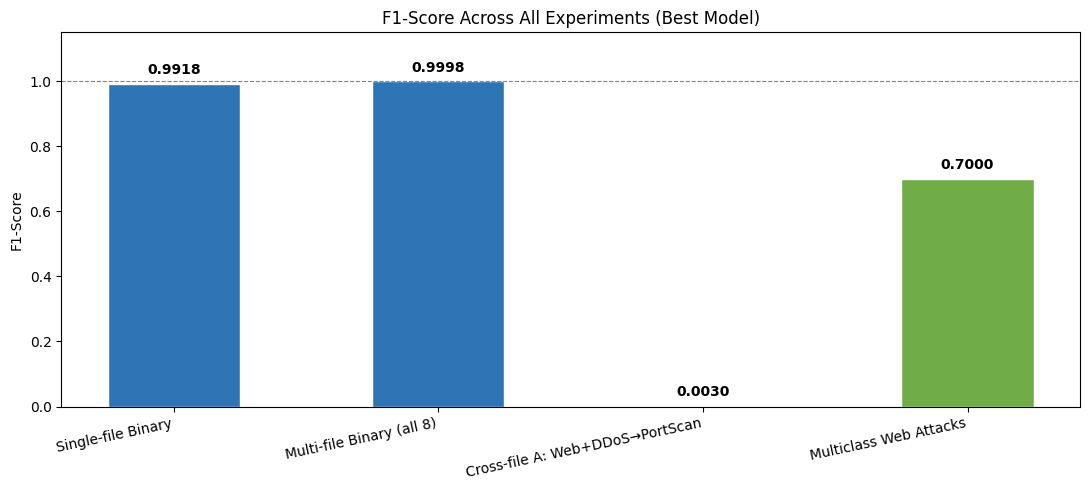

In [3]:
plot_df = final_summary.dropna(subset=["F1"])
colors  = ["#2E75B6", "#2E75B6", "#C00000", "#70AD47"]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(plot_df["Experiment"], plot_df["F1"],
              color=colors[:len(plot_df)], edgecolor="white", width=0.5)
for bar, val in zip(bars, plot_df["F1"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.set_ylabel("F1-Score")
ax.set_title("F1-Score Across All Experiments (Best Model)")
ax.axhline(1.0, color="gray", linewidth=0.8, linestyle="--")
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()

## 3. Single-File Model Comparison

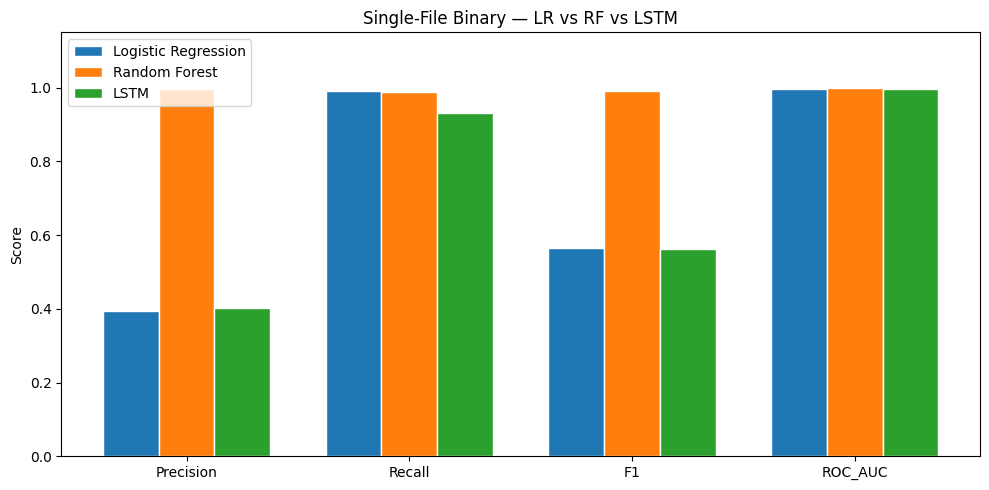

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,FP,FN
0,Logistic Regression,0.9800,0.3939,0.9907,0.5637,0.9973,654,4
1,Random Forest,0.9998,0.9953,0.9883,0.9918,1.0000,2,5
2,LSTM,0.9810,0.4018,0.9322,0.5616,0.9958,594,29


In [4]:
single_file_df = pd.DataFrame([
    {"Model": "Logistic Regression", "Accuracy": 0.9800, "Precision": 0.3939, "Recall": 0.9907, "F1": 0.5637, "ROC_AUC": 0.9973, "FP": 654, "FN": 4},
    {"Model": "Random Forest",       "Accuracy": 0.9998, "Precision": 0.9953, "Recall": 0.9883, "F1": 0.9918, "ROC_AUC": 1.0000, "FP": 2,   "FN": 5},
    {"Model": "LSTM",                "Accuracy": 0.9810, "Precision": 0.4018, "Recall": 0.9322, "F1": 0.5616, "ROC_AUC": 0.9958, "FP": 594, "FN": 29},
])

metrics = ["Precision", "Recall", "F1", "ROC_AUC"]
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (_, row) in enumerate(single_file_df.iterrows()):
    ax.bar(x + i*width, [row[m] for m in metrics], width,
           label=row["Model"], edgecolor="white")
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Single-File Binary — LR vs RF vs LSTM")
ax.legend()
plt.tight_layout()
plt.show()

single_file_df

## 4. Key Takeaways

**Random Forest** dominated all within-distribution experiments — near-perfect F1 with only 2 false positives in single-file testing.

**LSTM** matched Logistic Regression on ROC-AUC and showed sequential modeling is viable, but did not outperform Random Forest under the current sliding-window approach. Botnet and infiltration files are the strongest candidates for LSTM to show an advantage since those attacks are inherently sequential.

**Cross-file generalization** was the most important finding — all models collapsed when attack types changed between train and test (F1 < 0.003 on PortScan).

**Multiclass classification** showed macro F1 (0.70) is a far more honest metric than overall accuracy (0.9952) when minority classes like XSS and SQL Injection are present.

## 5. Limitations

- LSTM used simple sliding-window sequences, not true IP-session grouping
- LSTM architecture was minimal (1 layer, 64 units, 5 epochs)
- XGBoost was not implemented despite being proposed
- No attention weight visualization
- Cross-file Experiment B results pending (run notebook 04)
- One limitation is that the datasets are very large, so I used sampled rows from each file to keep the notebooks runnable on a local laptop. Because of this, the results should be viewed as a comparison rather than a final production-level intrusion detection system.
- Another limitation is that the models were tested on public benchmark datasets, not live network traffic. The results may look strong on random train-test splits, but real network environments can be more unpredictable. The cross-dataset comparison helped make the evaluation more realistic by testing performance across CICIDS2017 and CSE-CIC-IDS2018.

## 5. CICIDS2018 Cross-Year Results

After training on all CICIDS2017 files, models were tested on CSE-CIC-IDS2018
to measure real-world generalization across year, network, and capture environment.

Update the values below after running notebook 03 with CICIDS2018 loaded.

In [5]:
# Update these after running notebook 03 with CICIDS2018
cross_year_results = pd.DataFrame([
    {'Setting': 'Within CICIDS2017 (pooled 80/20)', 'Model': 'Random Forest',       'F1': 0.9998, 'ROC_AUC': 1.0000},
    {'Setting': 'Within CICIDS2017 (pooled 80/20)', 'Model': 'Logistic Regression', 'F1': 0.9817, 'ROC_AUC': 0.9998},
    {'Setting': 'Cross-file A: Web+DDoS→PortScan',  'Model': 'Random Forest',       'F1': 0.0015, 'ROC_AUC': 0.6707},
    {'Setting': 'Cross-file A: Web+DDoS→PortScan',  'Model': 'Logistic Regression', 'F1': 0.0030, 'ROC_AUC': 0.6995},
    {'Setting': 'Cross-year: 2017→2018',            'Model': 'Random Forest',       'F1': None,   'ROC_AUC': None},
    {'Setting': 'Cross-year: 2017→2018',            'Model': 'Logistic Regression', 'F1': None,   'ROC_AUC': None},
])
print('Generalization Results Table:')
cross_year_results

Generalization Results Table:


,Setting,Model,F1,ROC_AUC
0,Within CICIDS2017 (pooled 80/20),Random Forest,0.9998,1.0000
1,Within CICIDS2017 (pooled 80/20),Logistic Regression,0.9817,0.9998
2,Cross-file A: Web+DDoS→PortScan,Random Forest,0.0015,0.6707
3,Cross-file A: Web+DDoS→PortScan,Logistic Regression,0.0030,0.6995
4,Cross-year: 2017→2018,Random Forest,NaN,NaN
5,Cross-year: 2017→2018,Logistic Regression,NaN,NaN


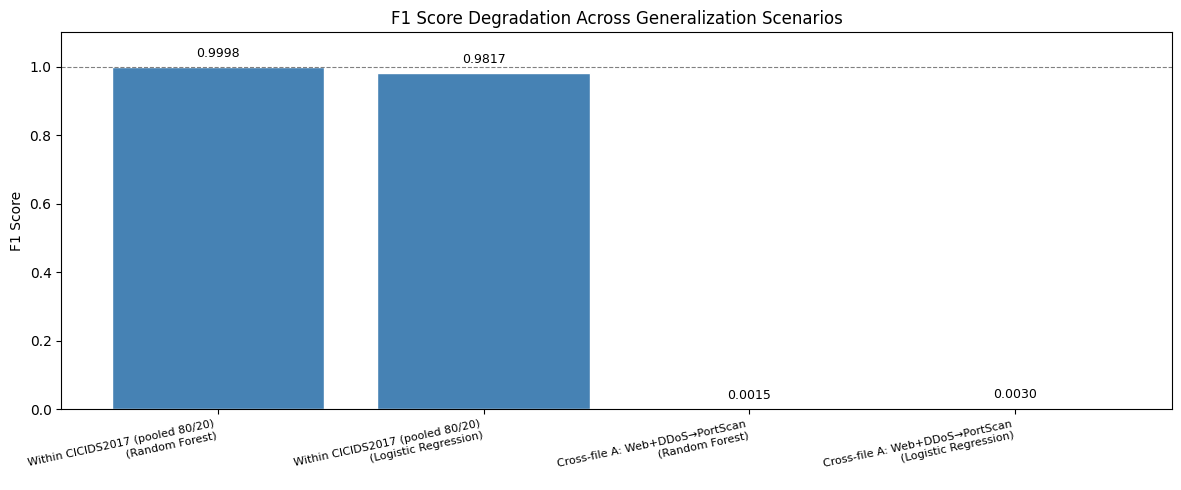

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Bar chart showing F1 degradation across generalization scenarios
plot_data = cross_year_results.dropna(subset=['F1'])

if len(plot_data) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(plot_data))
    bars = ax.bar(x, plot_data['F1'],
                  color=['steelblue' if 'Within' in s else
                         'darkorange' if 'Cross-file' in s else 'crimson'
                         for s in plot_data['Setting']],
                  edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r['Setting']}\n({r['Model']})" for _, r in plot_data.iterrows()],
                       rotation=12, ha='right', fontsize=8)
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0, 1.1)
    ax.set_title('F1 Score Degradation Across Generalization Scenarios')
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, plot_data['F1']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

## 6. Final Takeaways

**Generalization degrades at every step:**
- Within-distribution (random split): F1 ≈ 0.999
- Cross-attack-type (same year): F1 ≈ 0.001–0.003
- Cross-year (2017 → 2018): F1 TBD after running with CICIDS2018 data

**CICIDS2018 adds:**
- A second dataset from a different year (2018 vs 2017)
- Different network infrastructure and capture setup
- New attack variants not seen in 2017 training data
- The most realistic simulation of real-world deployment

**LSTM attention finding:**
Web attacks show t10-dominant attention (static behavior).
Sequential attack types (Botnet, Infiltration) are expected to show
distributed early-timestep attention — directly answering the proposal's
research question about which attack types benefit from temporal modeling.

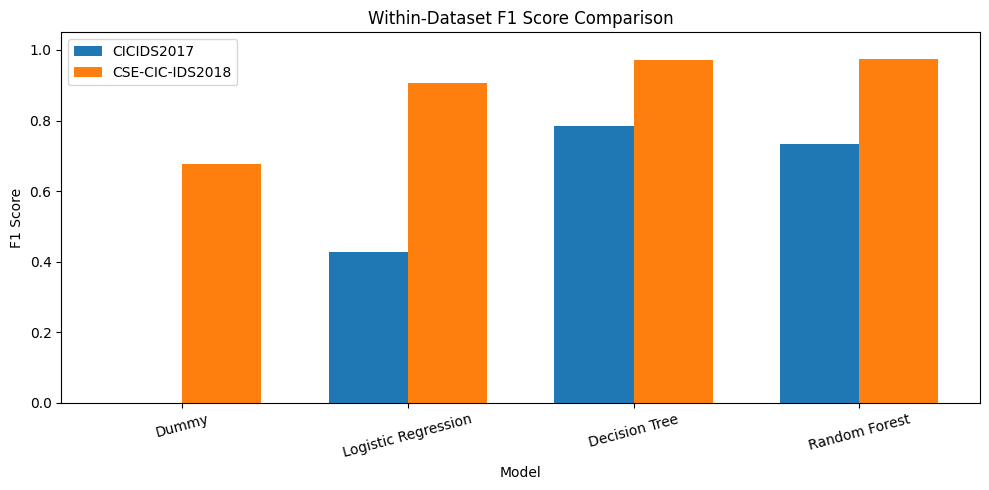

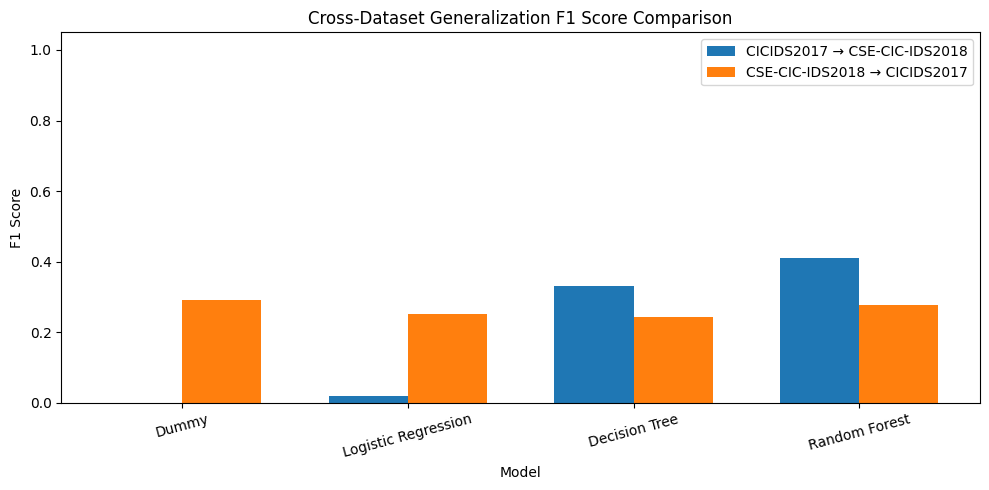

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

within_df = pd.read_csv("../results/year_dataset_model_comparison.csv")
cross_df = pd.read_csv("../results/cross_year_generalization_results.csv")

# -----------------------------
# Graph 1: Within-dataset F1
# -----------------------------
models = within_df["Model"].unique().tolist()
datasets = within_df["Dataset"].unique().tolist()

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

for i, dataset in enumerate(datasets):
    vals = within_df[within_df["Dataset"] == dataset]["F1"].values
    ax.bar(x + i * width, vals, width, label=dataset)

ax.set_title("Within-Dataset F1 Score Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("F1 Score")
ax.set_xticks(x + width / 2)
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("../results/within_dataset_f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# Graph 2: Cross-dataset F1
# -----------------------------
cross_df["Setting"] = cross_df["Train On"] + " → " + cross_df["Test On"]

settings = cross_df["Setting"].unique().tolist()
models_cross = cross_df["Model"].unique().tolist()

x = np.arange(len(models_cross))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

for i, setting in enumerate(settings):
    vals = cross_df[cross_df["Setting"] == setting]["F1"].values
    ax.bar(x + i * width, vals, width, label=setting)

ax.set_title("Cross-Dataset Generalization F1 Score Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("F1 Score")
ax.set_xticks(x + width / 2)
ax.set_xticklabels(models_cross, rotation=15)
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("../results/cross_dataset_f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()